In [3]:
# ============================================================
# CELDA 1: PREPARAR VARIABLES PARA EL MODELO
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Verificar que las columnas necesarias existan
columnas_necesarias = ["dia", "inflacion", "tasa_interes", "precio_dolar"]

for columna in columnas_necesarias:
    if columna not in df_dolar.columns:
        print(f"Falta la columna: {columna}")

# Seleccionar solo las columnas necesarias para el modelo
df_modelo = df_dolar[["dia", "inflacion", "tasa_interes", "precio_dolar"]].copy()

# Asegurar que todas sean numéricas
df_modelo["dia"] = pd.to_numeric(df_modelo["dia"], errors="coerce")
df_modelo["inflacion"] = pd.to_numeric(df_modelo["inflacion"], errors="coerce")
df_modelo["tasa_interes"] = pd.to_numeric(df_modelo["tasa_interes"], errors="coerce")
df_modelo["precio_dolar"] = pd.to_numeric(df_modelo["precio_dolar"], errors="coerce")

# Eliminar posibles valores nulos después de convertir
df_modelo = df_modelo.dropna()

# Variables independientes
X = df_modelo[["dia", "inflacion", "tasa_interes"]]

# Variable dependiente
y = df_modelo["precio_dolar"]

print("Datos listos para entrenar el modelo.")
print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

df_modelo.head()

Datos listos para entrenar el modelo.
Tamaño de X: (500, 3)
Tamaño de y: (500,)


,dia,inflacion,tasa_interes,precio_dolar
0,1,0.022484,5.463089,4024.833598
1,2,0.019309,5.954708,4000.546337
2,3,0.023238,4.300716,3979.622045
3,4,0.027615,5.281485,3940.361345
4,5,0.018829,4.674679,4016.930225


In [4]:
# ============================================================
# CELDA 2: ENTRENAR MODELO DE REGRESIÓN LINEAL MÚLTIPLE
# ============================================================

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Crear modelo
modelo_dolar = LinearRegression()

# Entrenar modelo
modelo_dolar.fit(X_train, y_train)

print("Modelo de regresión lineal múltiple entrenado correctamente.")
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Modelo de regresión lineal múltiple entrenado correctamente.
Datos de entrenamiento: (400, 3)
Datos de prueba: (100, 3)


In [5]:
# ============================================================
# CELDA 3: INTERPRETAR COEFICIENTES DEL MODELO
# ============================================================

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_dolar.coef_
})

intercepto = modelo_dolar.intercept_

print("===== ECUACIÓN DEL MODELO =====")
print(
    f"precio_dolar = {intercepto:.4f} "
    f"+ ({modelo_dolar.coef_[0]:.4f} * dia) "
    f"+ ({modelo_dolar.coef_[1]:.4f} * inflacion) "
    f"+ ({modelo_dolar.coef_[2]:.4f} * tasa_interes)"
)

print("\n===== COEFICIENTES =====")
display(coeficientes)

print("\n===== INTERPRETACIÓN =====")

for variable, coef in zip(X.columns, modelo_dolar.coef_):
    if coef > 0:
        print(f"- {variable}: tiene efecto positivo sobre el precio del dólar.")
        print(f"  Si {variable} aumenta en 1 unidad, el precio del dólar aumenta aproximadamente {coef:.4f}, manteniendo las demás variables constantes.\n")
    elif coef < 0:
        print(f"- {variable}: tiene efecto negativo sobre el precio del dólar.")
        print(f"  Si {variable} aumenta en 1 unidad, el precio del dólar disminuye aproximadamente {abs(coef):.4f}, manteniendo las demás variables constantes.\n")
    else:
        print(f"- {variable}: no presenta efecto sobre el precio del dólar.\n")

===== ECUACIÓN DEL MODELO =====
precio_dolar = 3985.5905 + (4.9843 * dia) + (-866.7460 * inflacion) + (-1.3526 * tasa_interes)

===== COEFICIENTES =====


,Variable,Coeficiente
0,dia,4.984273
1,inflacion,-866.745973
2,tasa_interes,-1.352610



===== INTERPRETACIÓN =====
- dia: tiene efecto positivo sobre el precio del dólar.
  Si dia aumenta en 1 unidad, el precio del dólar aumenta aproximadamente 4.9843, manteniendo las demás variables constantes.

- inflacion: tiene efecto negativo sobre el precio del dólar.
  Si inflacion aumenta en 1 unidad, el precio del dólar disminuye aproximadamente 866.7460, manteniendo las demás variables constantes.

- tasa_interes: tiene efecto negativo sobre el precio del dólar.
  Si tasa_interes aumenta en 1 unidad, el precio del dólar disminuye aproximadamente 1.3526, manteniendo las demás variables constantes.



In [6]:
# ============================================================
# CELDA 4: EVALUAR EL MODELO
# ============================================================

# Realizar predicciones con los datos de prueba
y_pred = modelo_dolar.predict(X_test)

# Calcular métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("===== EVALUACIÓN DEL MODELO =====")
print(f"Error Medio Cuadrático MSE: {mse:.4f}")
print(f"Raíz del Error Medio Cuadrático RMSE: {rmse:.4f}")
print(f"Coeficiente de determinación R²: {r2:.4f}")

print("\n===== INTERPRETACIÓN DEL DESEMPEÑO =====")

if r2 >= 0.80:
    print("El modelo tiene un buen desempeño, ya que explica una alta proporción de la variación del precio del dólar.")
elif r2 >= 0.50:
    print("El modelo tiene un desempeño aceptable, aunque todavía puede mejorar.")
else:
    print("El modelo tiene un desempeño bajo, posiblemente porque las variables no explican suficientemente el precio del dólar.")

print("\nEl MSE indica el error promedio cuadrático entre los valores reales y los valores predichos.")
print("Mientras menor sea el MSE, mejor es el desempeño del modelo.")

===== EVALUACIÓN DEL MODELO =====
Error Medio Cuadrático MSE: 2366.7189
Raíz del Error Medio Cuadrático RMSE: 48.6489
Coeficiente de determinación R²: 0.9963

===== INTERPRETACIÓN DEL DESEMPEÑO =====
El modelo tiene un buen desempeño, ya que explica una alta proporción de la variación del precio del dólar.

El MSE indica el error promedio cuadrático entre los valores reales y los valores predichos.
Mientras menor sea el MSE, mejor es el desempeño del modelo.


In [7]:
# ============================================================
# CELDA 5: VALIDACIÓN CRUZADA DEL MODELO
# ============================================================

scores_r2 = cross_val_score(
    modelo_dolar,
    X,
    y,
    cv=5,
    scoring="r2"
)

scores_mse = cross_val_score(
    modelo_dolar,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

mse_cv = -scores_mse

print("===== VALIDACIÓN CRUZADA =====")
print("R² en cada partición:", scores_r2)
print("Promedio R²:", scores_r2.mean())

print("\nMSE en cada partición:", mse_cv)
print("Promedio MSE:", mse_cv.mean())

print("\nEsta validación permite observar si el modelo mantiene un desempeño estable en diferentes partes del dataset.")

===== VALIDACIÓN CRUZADA =====
R² en cada partición: [0.89234985 0.86082701 0.89359776 0.8954905  0.87892789]
Promedio R²: 0.884238601619286

MSE en cada partición: [2246.6936991  3038.85691765 2487.38979776 2469.04678541 2903.37041251]
Promedio MSE: 2629.071522485402

Esta validación permite observar si el modelo mantiene un desempeño estable en diferentes partes del dataset.


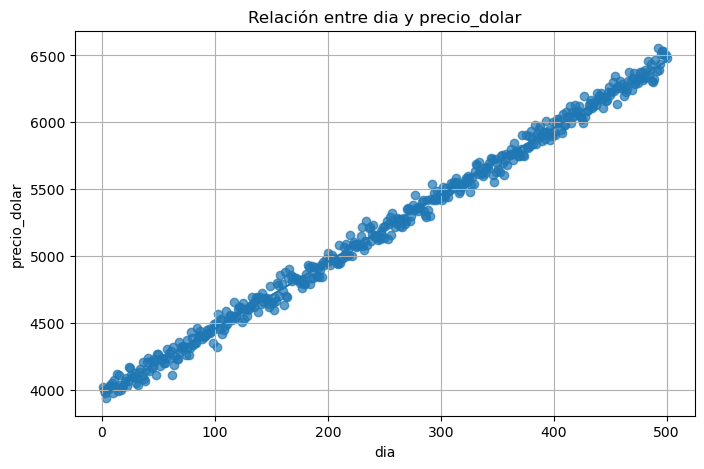

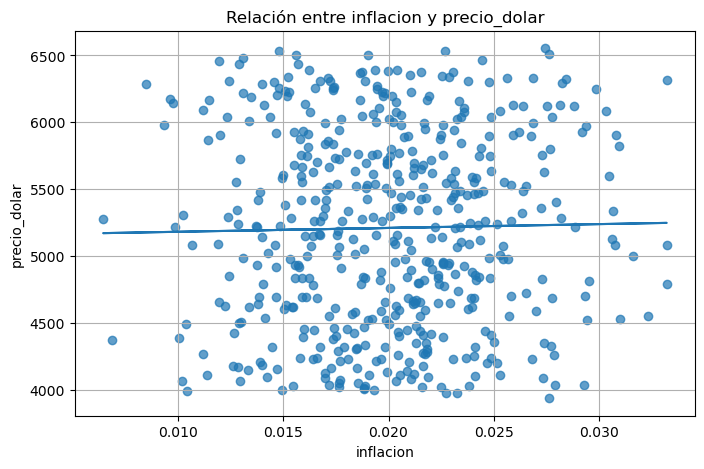

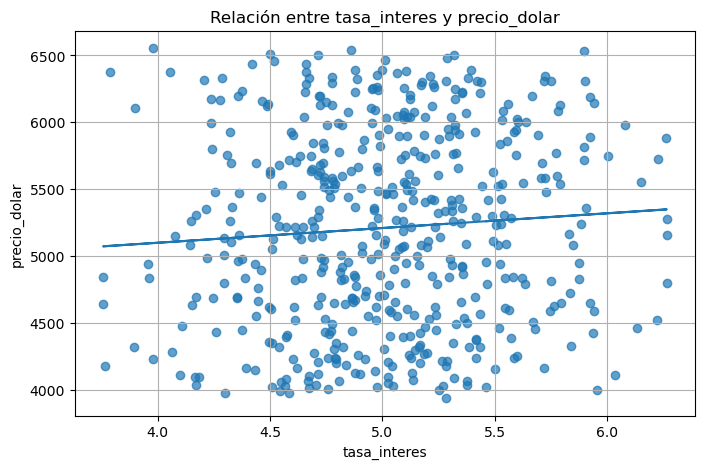

In [8]:
# ============================================================
# CELDA 6: GRAFICAR VARIABLES INDEPENDIENTES VS PRECIO_DOLAR
# ============================================================

variables_independientes = ["dia", "inflacion", "tasa_interes"]

for variable in variables_independientes:
    plt.figure(figsize=(8, 5))

    # Gráfico de dispersión
    plt.scatter(df_modelo[variable], df_modelo["precio_dolar"], alpha=0.7)

    # Línea de tendencia
    z = np.polyfit(df_modelo[variable], df_modelo["precio_dolar"], 1)
    p = np.poly1d(z)
    plt.plot(df_modelo[variable], p(df_modelo[variable]))

    plt.title(f"Relación entre {variable} y precio_dolar")
    plt.xlabel(variable)
    plt.ylabel("precio_dolar")
    plt.grid(True)
    plt.show()

===== MATRIZ DE CORRELACIÓN =====


,dia,inflacion,tasa_interes,precio_dolar
dia,1.000000,0.021570,0.075774,0.997579
inflacion,0.021570,1.000000,-0.077556,0.019130
tasa_interes,0.075774,-0.077556,1.000000,0.074065
precio_dolar,0.997579,0.019130,0.074065,1.000000


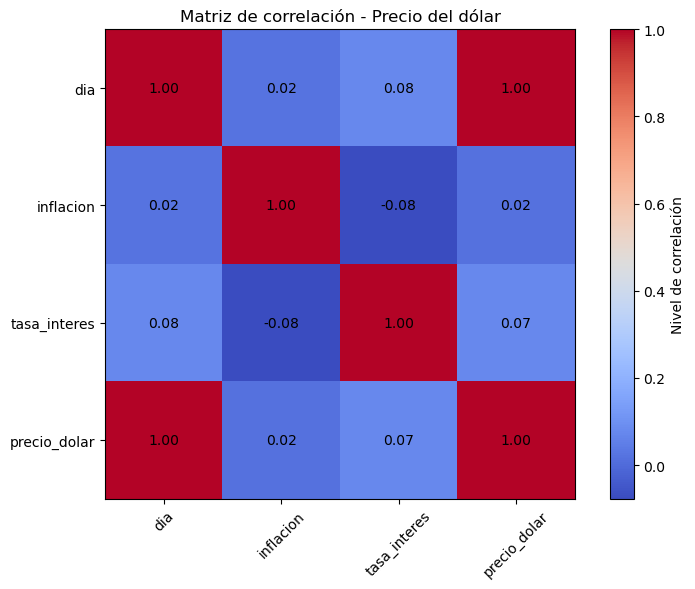

In [9]:
# ============================================================
# MATRIZ DE CORRELACIÓN - EJERCICIO DÓLAR
# ============================================================

import matplotlib.pyplot as plt

# Seleccionar solo las variables principales del modelo
df_correlacion = df_modelo[["dia", "inflacion", "tasa_interes", "precio_dolar"]]

# Calcular matriz de correlación
matriz_corr = df_correlacion.corr()

print("===== MATRIZ DE CORRELACIÓN =====")
display(matriz_corr)

# Graficar matriz de correlación
plt.figure(figsize=(8, 6))

plt.imshow(matriz_corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Nivel de correlación")

# Etiquetas
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=45)
plt.yticks(range(len(matriz_corr.columns)), matriz_corr.columns)

# Mostrar valores dentro de cada celda
for i in range(len(matriz_corr.columns)):
    for j in range(len(matriz_corr.columns)):
        plt.text(
            j, i,
            f"{matriz_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Matriz de correlación - Precio del dólar")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# EXPORTAR MODELO Y VARIABLES EN UN SOLO ARCHIVO
# ============================================================

import joblib
import os

os.makedirs("modelos", exist_ok=True)

paquete_dolar = {
    "modelo": modelo_dolar,
    "variables": ["dia", "inflacion", "tasa_interes"],
    "variable_objetivo": "precio_dolar",
    "nombre_modelo": "Predicción del precio del dólar"
}

joblib.dump(paquete_dolar, "modelos/paquete_modelo_dolar.joblib")

print("Paquete del modelo exportado correctamente.")
print("Archivo creado: modelos/paquete_modelo_dolar.joblib")

Paquete del modelo exportado correctamente.
Archivo creado: modelos/paquete_modelo_dolar.joblib


In [11]:
# ============================================================
# PROBAR PAQUETE COMPLETO DEL MODELO
# ============================================================

import joblib
import pandas as pd

paquete = joblib.load("modelos/paquete_modelo_dolar.joblib")

modelo = paquete["modelo"]
variables = paquete["variables"]

print("Nombre del modelo:", paquete["nombre_modelo"])
print("Variables del modelo:", variables)
print("Variable objetivo:", paquete["variable_objetivo"])

nuevo_dato = pd.DataFrame({
    "dia": [15],
    "inflacion": [0.023],
    "tasa_interes": [4.8]
})

prediccion = modelo.predict(nuevo_dato)

print(f"Predicción del precio del dólar: {prediccion[0]:.2f}")

Nombre del modelo: Predicción del precio del dólar
Variables del modelo: ['dia', 'inflacion', 'tasa_interes']
Variable objetivo: precio_dolar
Predicción del precio del dólar: 4033.93
